In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


RESULTS_CSV = "/content/drive/MyDrive/Gloves_det_Project/runs/ppe_glove-2/results.csv"
SAVE_DIR = Path("/content/drive/MyDrive/Gloves_det_Project/runs/ppe_glove-2/training_plots")

SAVE_DIR.mkdir(exist_ok=True)


df = pd.read_csv(RESULTS_CSV)

In [4]:
df

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,63.5465,1.86993,3.22086,1.75450,0.07661,0.20415,0.05216,0.02622,1.95206,15.52560,1.91228,0.000317,0.000317,0.068650
1,2,87.7911,1.77926,2.31736,1.66977,0.08444,0.15587,0.02484,0.01279,2.07298,107.63000,2.19020,0.000649,0.000649,0.035649
2,3,115.2830,1.91307,2.28786,1.82888,0.00947,0.07804,0.00435,0.00124,2.51391,53.45340,2.66278,0.000979,0.000979,0.002646
3,4,143.3400,1.88074,2.20458,1.71891,0.03329,0.07257,0.01072,0.00405,2.31377,43.53910,2.90702,0.000991,0.000991,0.000991
4,5,165.9250,1.80270,1.93157,1.70805,0.01745,0.22500,0.01212,0.00424,2.35053,75.89910,2.65005,0.000984,0.000984,0.000984
5,6,192.7640,1.79634,1.62644,1.69546,0.03750,0.13300,0.01841,0.00809,2.11897,71.84820,2.33846,0.000976,0.000976,0.000976
6,7,222.1270,1.73248,1.50081,1.60618,0.41667,0.04808,0.06703,0.01942,2.14533,21.57450,2.28473,0.000965,0.000965,0.000965
7,8,251.0070,1.76132,1.77223,1.70625,0.23836,0.43122,0.24565,0.10021,1.92182,13.48490,1.99925,0.000953,0.000953,0.000953
8,9,282.7560,1.70604,1.44958,1.61854,0.23268,0.46060,0.19225,0.08537,1.98841,5.30139,2.01092,0.000939,0.000939,0.000939
9,10,313.9740,1.66598,1.44332,1.61049,0.19517,0.26366,0.13500,0.06405,2.23206,4.99662,2.24018,0.000923,0.000923,0.000923


In [5]:
# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


In [6]:
def plot_metric(y_cols, title, ylabel, filename):
    plt.figure(figsize=(8,5))

    for col in y_cols:
        if col in df.columns:
            plt.plot(df["epoch"], df[col], linewidth=2, label=col)

    plt.title(title, fontsize=14)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()

    plt.savefig(SAVE_DIR / filename, dpi=300)
    plt.show()


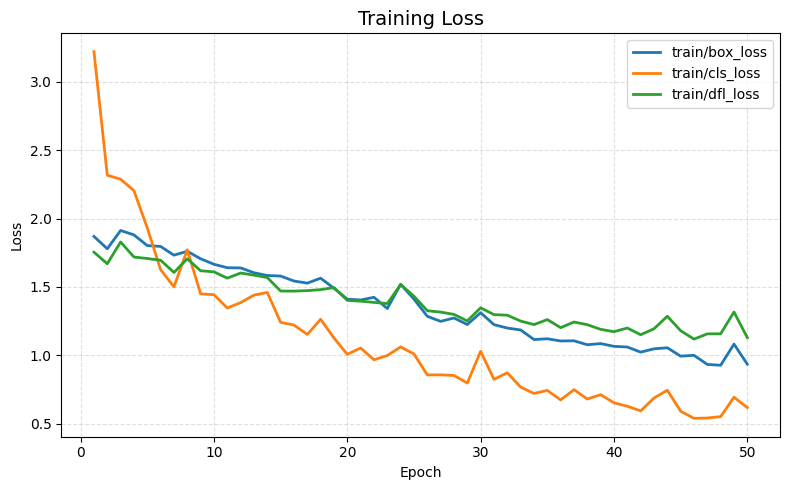

In [7]:
#training loss
plot_metric([
        "train/box_loss",
        "train/cls_loss",
        "train/dfl_loss"],
    "Training Loss",
    "Loss",
    "training_loss.png"
)

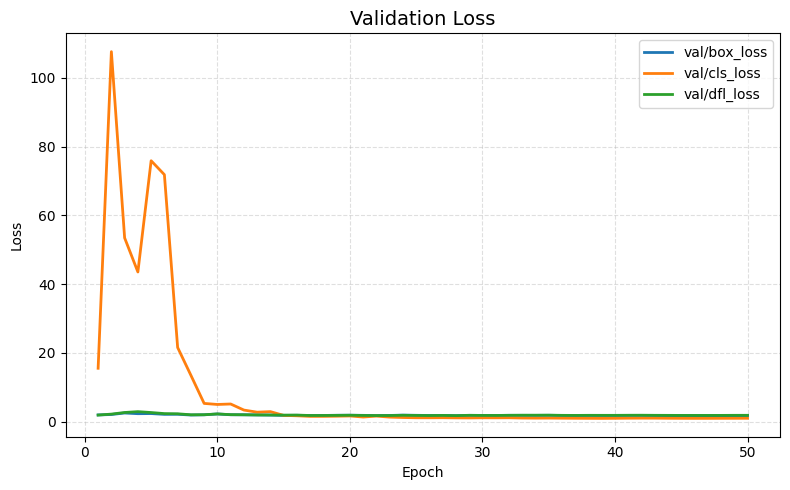

In [8]:
# Validation Loss
plot_metric(
    [
        "val/box_loss",
        "val/cls_loss",
        "val/dfl_loss"
    ],
    "Validation Loss",
    "Loss",
    "validation_loss.png"
)

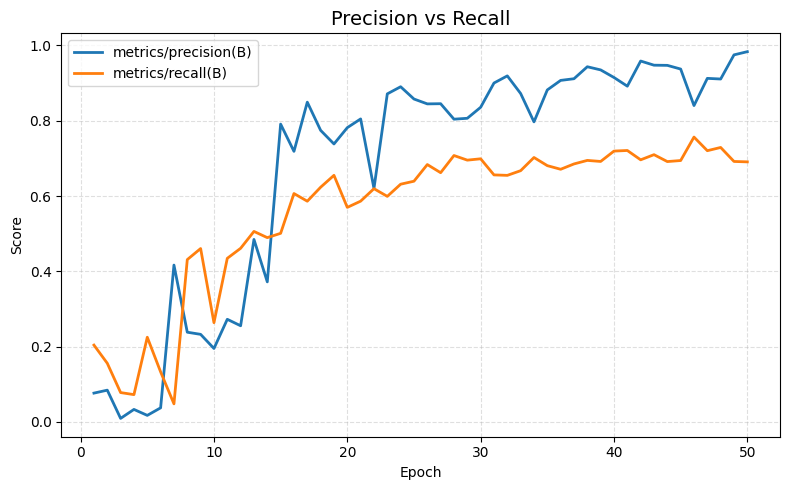

In [9]:
# Precision Recall
plot_metric(
    [
        "metrics/precision(B)",
        "metrics/recall(B)"
    ],
    "Precision vs Recall",
    "Score",
    "precision_recall.png"
)

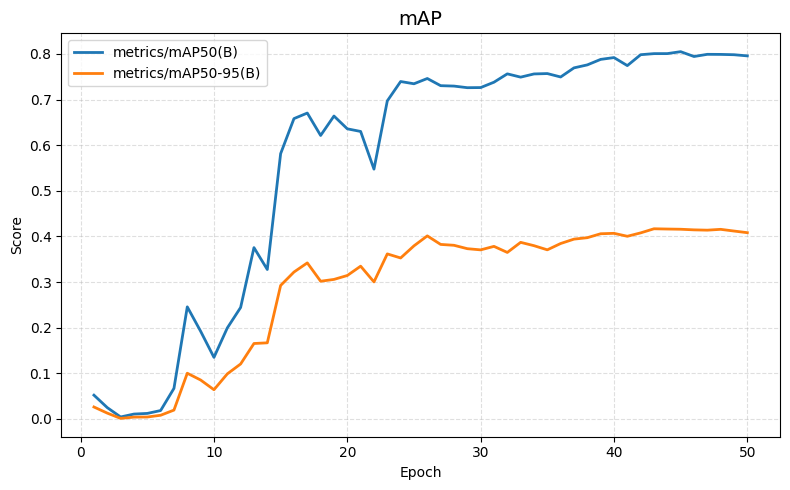

In [11]:
#mAP

plot_metric(
    [
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)"
    ],
    "mAP",
    "Score",
    "map.png"
)

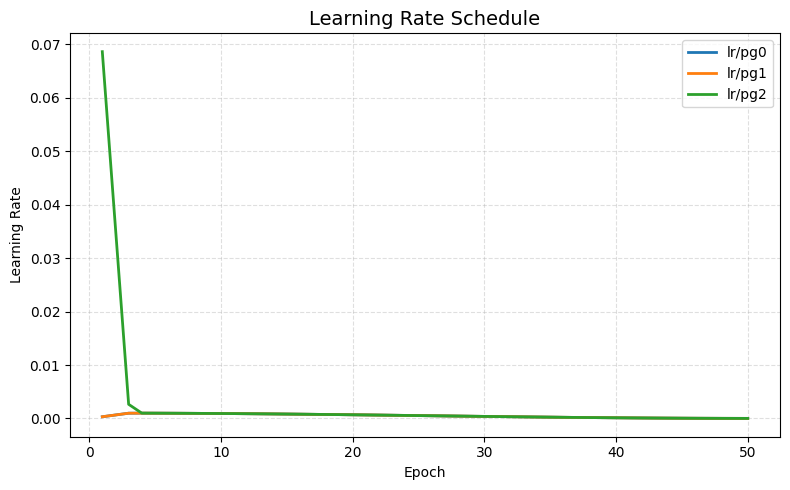

In [15]:
#learning rate
lr_cols = [c for c in df.columns if c.startswith("lr/")]

plot_metric(
    lr_cols,
    "Learning Rate Schedule",
    "Learning Rate",
    "learning_rate.png"
)